In [175]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [176]:
!pip install networkx


In [177]:
import networkx as nx

In [178]:
#Prompt the user
n= int(input ("Enter the number of people in the social network:"))

Enter the number of people in the social network: 5


In [179]:
edges = set() #use a set to avoid duplicate edges

In [180]:
#Functions to generate a realistic number of connections per person
def realistic_connections(n):
    """
    Generates a random number of connections based on a heavy-tailed distribution
    """
    percent = np.random.beta(2, 5) #skewed towards smaller percentages
    count = int(percent*(n-1))
    count = max(1, min(count, n-1)) #at least 1, at most n-1
    return count
    

In [181]:
#Generate edges
for person in range(1, n+1):
    num_connections = realistic_connections(n)
    possible_connections = [i for i in range (1, n+1) if i != person]
    connected_people = random.sample(possible_connections, k=num_connections)
    for other in connected_people:
        edge=tuple(sorted((person, other)))
        edges.add(edge)
        
edges = list(edges)

In [182]:
G = nx.Graph()
G.add_edges_from(edges)

In [183]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

<Figure size 1000x800 with 0 Axes>

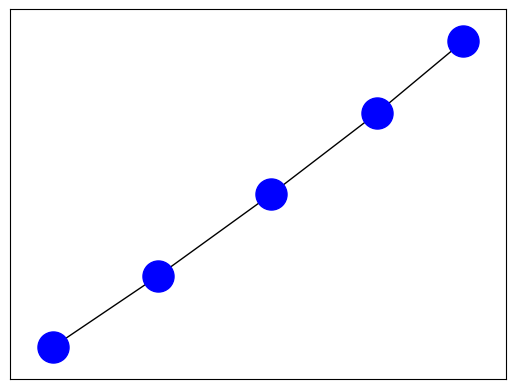

In [184]:
#draw nodes and edges
nx.draw_networkx_nodes(G, pos, node_color='blue', node_size = 500)
nx.draw_networkx_edges(G, pos, edge_color='black')

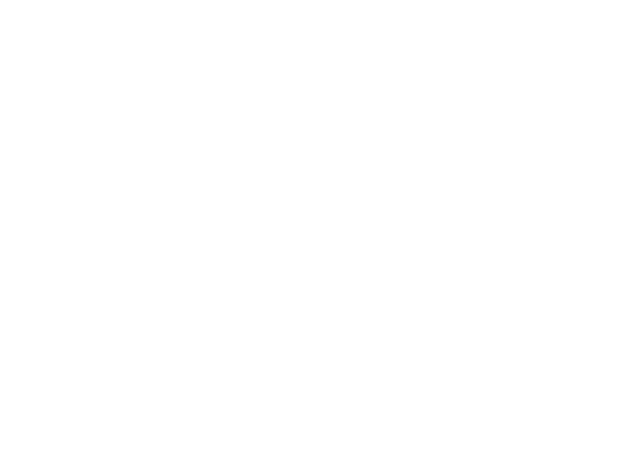

In [185]:
plt.axis('off')
plt.tight_layout()
plt.show()

In [186]:
if nx.is_connected(G):
    diameter = nx.diameter(G)
    radius = nx.radius(G)
    center = nx.center(G)
else:
    print("-Graph is NOT connected.")

print(f"-Diameter:{diameter}")
print(f"-Radius:{radius}")
print(f"-Center{center}")

                       

-Diameter:4
-Radius:2
-Center[4]
